# Jailbreaking LLMs

### This is a small experiment working on understanding how LLMs represent harmful and harmless prompts. This loosely follows the experiments demonstrated by [Lin et al. 2024](https://arxiv.org/abs/2406.10794).

In [ ]:
! pip install --quiet huggingface_hub

from huggingface_hub import notebook_login
notebook_login()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoModelForCausalLM, AutoTokenizer

# load model and tokenizer
model_name = "meta-llama/Meta-Llama-3-8B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

Here, I am loading in harmless and harmful prompts taken from the experiments done by [Zheng et al. 2024](https://github.com/chujiezheng/LLM-Safeguard?tab=readme-ov-file). Then, by taking the last token of these prompts, we can see how these prompts are being represented by the LLM. The intuition behind why we can look at the last token is that the last token contains the information from all the previous tokens. This last token's representation can therefore serve as a summary of the model's understanding of the prompt.

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


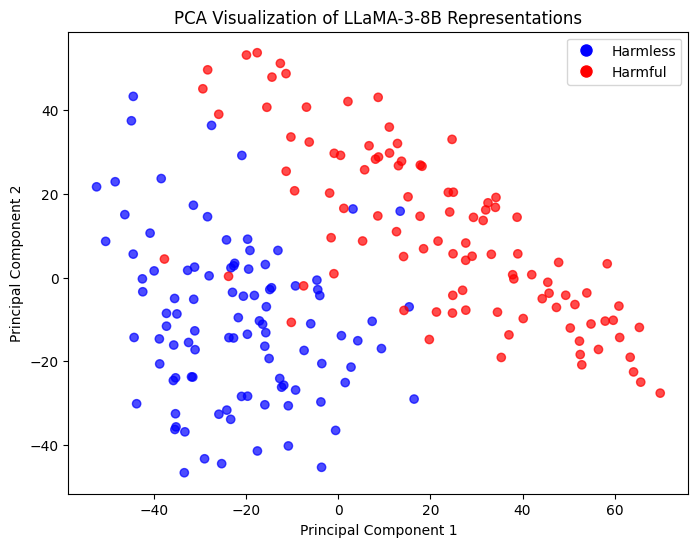

In [ ]:
def load_prompts(filename):
    with open(filename, "r", encoding="utf-8") as file:
        return [line.strip() for line in file.readlines() if line.strip()]

prompts = {
    "harmless": load_prompts("harmless.txt"),
    "harmful": load_prompts("harmful.txt"),
}

# extract last hidden states
def get_last_hidden_state(prompt):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    last_hidden_state = outputs.hidden_states[-1]  # Last layer hidden states
    return last_hidden_state[:, -1, :].cpu().numpy()  # Last token representation

embeddings = []
labels = []
colors = []
color_map = {"harmless": "blue", "harmful": "red"}

for label, prompt_list in prompts.items():
    for prompt in prompt_list:
        embedding = get_last_hidden_state(prompt)
        embeddings.append(embedding)
        labels.append(label)
        colors.append(color_map[label])


embeddings = np.vstack(embeddings)

# PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=colors, alpha=0.7)
plt.title("PCA Visualization of LLaMA-3-8B Representations")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Harmless'),
                     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Harmful')])
plt.show()

After using PCA, we can see a clear boundary between how harmless and harmful statements are being represented by the model.

Next, we can use a jailbreaking algorithm to see how the representations of these harmful prompts change. Intuitively, we should see a shift in their representation towards the harmless prompts.